# CS 524: Introduction to Optimization: Multi-Objective Diet Optimization with Habituation-Adjusted Satisfaction

**Name: Shashwat Negi**  
**Email: Negi3@wisc.edu**

---

## Table of Contents
1. [Introduction](#1-introduction)
2. [Description of the Approach Used](#2-methodology-and-approach)
3. [Optimization Model and Solution](#3-optimization-model-and-solution)
4. [Results and Sensitivity Analysis](#4-results-and-sensitivity-analysis)
5. [Conclusions](#5-conclusions)
6. [Further Reading and Extensions](#6-further-reading-and-extensions)

---

### Prerequisites for this notebook:
- Python 3.8+
- GAMSPy, NumPy, Pandas, Matplotlib, Seaborn
- Required data files: `nutrient_data.csv`, `food_prices.csv`, `food_satisfaction.csv`, `nutrient_constraints.csv`, `model_config.csv`

---


In [1]:
# Import libraries
import numpy as np
import pandas as pd
import gamspy as gp
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configure plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("Libraries imported successfully")

Libraries imported successfully


# 1. Introduction

### 1.1 Motivation

As an international graduate student balancing coursework, teaching responsibilities, and fitness goals, I face a critical challenge: meeting nutritional requirements within a tight budget and limited time. With a monthly income of $1,300 and fixed expenses, I have approximately $300 monthly ($70-$100 weekly) for food. However, the challenge extends beyond simple cost minimization—I must address several unique aspects:

**What makes this problem unique:**
1. **Multi-objective trade-offs**: Balancing cost minimization with satisfaction maximization (not just finding the cheapest meal)
2. **Habituation effects**: Accounting for diminishing satisfaction when eating the same foods repeatedly
3. **Time constraints**: Limited time for meal preparation requires reliance on restaurant/takeout options near campus
4. **Nutritional completeness**: Meeting 17 different nutrient requirements (macro and micronutrients) across a full week
5. **Variety-seeking behavior**: Ensuring meal diversity to maintain long-term dietary adherence
6. **Budget flexibility**: Operating within a range ($70-$350 weekly) rather than a strict fixed budget

A simple "minimize cost" approach would yield monotonous meal plans that are impractical to follow. This motivated developing a sophisticated optimization model that systematically addresses food selection while ensuring adequate nutrition, sustained satisfaction, and practical feasibility.

### 1.2 Problem Statement

This project addresses the **Multi-Objective 7-Day Diet Planning Problem** with explicit consideration of **habituation effects**—the phenomenon where consuming the same food repeatedly leads to diminishing satisfaction. Using food items from restaurants near UW-Madison, the goal is to design a weekly meal plan that:

- **Provides variety** through balanced meal structure (mains, desserts, drinks)
- **Minimizes weekly cost** within a $70-$350 budget range
- **Maximizes satisfaction** adjusted for habituation effects to ensure dietary adherence
- **Meets nutritional requirements** for 17 nutrients (calories, protein, carbs, fats, vitamins, minerals, fiber, sodium)
- **Respects practical constraints** (serving sizes, maximum repetitions)

**Decision Variables:** Which foods to select each day and how many servings of each.

### 1.3 Approach and Contribution

We formulate this as a **Mixed-Integer Linear Program (MILP)** with 540 variables and ~618 constraints. The key innovation is a **simplified habituation model** that maintains linearity for efficient solving while capturing satisfaction decay. Our contributions include:

1. **Linearized habituation model**: Tractable formulation enabling optimal solutions in under 60 seconds
2. **Pareto frontier analysis**: Reveals optimal trade-offs between conflicting cost and satisfaction objectives
3. **Practical applicability**: Generates actionable meal plans for graduate students, institutional dining, and nutritional counseling

This work demonstrates how operations research techniques can solve real-world personal finance problems while maintaining computational efficiency.

In [2]:
# Define food categories
expanded_nutrients = [
    "Calories", "Protein", "Carbs", "Fat", "SaturatedFat", "TransFat", "Sugars",
    "Sodium", "Fiber", "VitaminA", "VitaminC", "VitaminD", "Calcium", "Iron", 
    "Potassium", "Cholesterol", "Caffeine"
]

restaurants_dict = {
    "Chipotle": {"Main": ["Chicken_Burrito", "Steak_Bowl", "Veggie_Tacos"], "Dessert": ["Churros"]},
    "Subway": {"Main": ["Turkey_Sandwich", "Veggie_Delite", "Chicken_Teriyaki", "Meatball_Marinara"]},
    "McDonalds": {"Main": ["Big_Mac", "Quarter_Pounder", "Chicken_Nuggets"], "Dessert": ["Vanilla_Cone"]},
    "PizzaHut": {"Main": ["Pepperoni_Pizza", "Cheese_Pizza", "Veggie_Pizza"], "Dessert": ["Brownie"]},
    "TacoBell": {"Main": ["Crunchwrap", "Taco", "Burrito"], "Dessert": ["Cinnamon_Twist"]},
    "Starbucks": {"Drink": ["Latte", "Cappuccino", "Frappuccino"], "Dessert": ["Muffin", "Croissant"]},
    "Dunkin": {"Drink": ["Coffee"], "Dessert": ["Donut", "Cheese_Cake"]},
    "DailyScoop": {"Dessert": ["Vanilla_Cone", "Chocolate_Sundae", "Strawberry_Scoop", "Cookie_Dough"]},
    "ColdStone": {"Dessert": ["IceCream_Cake"], "Drink": ["Smoothie", "Milkshake"]}
}

food_categories = {"Main": [], "Dessert": [], "Drink": []}
food_list = []
for restaurant, categories in restaurants_dict.items():
    for category, items in categories.items():
        for item in items:
            food_name = f"{restaurant}_{item}"
            food_list.append(food_name)
            food_categories[category].append(food_name)

days_list = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Load data
df = pd.read_csv("nutrient_data.csv")
nutrient_values = {}
for _, row in df.iterrows():
    item = row['Restaurant_MenuItem']
    nutrient_values[item] = {n: row[n] for n in expanded_nutrients}

nutrient_data_expanded = [(food, nutrient, nutrient_values[food].get(nutrient, 0)) 
                          for food in food_list for nutrient in expanded_nutrients]

# Load parameters
prices_df = pd.read_csv("food_prices.csv")
price_data = prices_df[['Food', 'Price']].copy()
price_data.columns = ['foods', 'value']

satisfaction_df = pd.read_csv("food_satisfaction.csv")
sat_data = satisfaction_df[['Food', 'Base_Satisfaction']].copy()
sat_data.columns = ['foods', 'value']

hab_data = satisfaction_df[['Food', 'Habituation_Rate']].copy()
hab_data.columns = ['foods', 'value']

constraints_df = pd.read_csv("nutrient_constraints.csv")
Nmin_data = constraints_df[['Nutrient', 'Nmin']].copy()
Nmin_data['Nmin'] = Nmin_data['Nmin'] * 7
Nmin_data.columns = ['nutrients', 'value']

Nmax_data = constraints_df[['Nutrient', 'Nmax']].copy()
Nmax_data['Nmax'] = Nmax_data['Nmax'] * 7
Nmax_data.columns = ['nutrients', 'value']

config_df = pd.read_csv("model_config.csv")
config_values = config_df.set_index('Parameter')['Value'].to_dict()

budget_min = float(config_values['budget_min']) * 7
budget_max = float(config_values['budget_max']) * 7
max_servings = int(config_values['max_servings_per_food'])

print("Data Loaded Successfully:")
print(f"  Restaurants: {len(restaurants_dict)}")
print(f"  Total Foods: {len(food_list)} (Mains: {len(food_categories['Main'])}, Desserts: {len(food_categories['Dessert'])}, Drinks: {len(food_categories['Drink'])})")
print(f"  Nutrients: {len(expanded_nutrients)}")
print(f"  Weekly Budget: ${budget_min:.0f} - ${budget_max:.0f}")
print(f"  Planning Horizon: 7 days")

Data Loaded Successfully:
  Restaurants: 9
  Total Foods: 35 (Mains: 16, Desserts: 13, Drinks: 6)
  Nutrients: 17
  Weekly Budget: $35 - $350
  Planning Horizon: 7 days


### Fetch Nutritional Data from the Nutritionix API

In [3]:
#Nutritional data from Nutritionix API
from IPython.display import HTML, display
display(HTML('<iframe src="https://www.nutritionix.com/subway/nutrition-calculator" width="100%" height="800"></iframe>'))


# 2. Methodology and Approach

### 2.1 Model Type: Mixed-Integer Linear Program (MILP)

This problem is formulated as a **Mixed-Integer Linear Program** due to:
- **Binary indicator variables**: $y_{it} \in \{0, 1\}$ determine whether a food is selected
  - $y_{it} = 1$ when food $i$ is selected on day $t$
  - $y_{it} = 0$ when food $i$ is not selected on day $t$
- **Integer variables**: $x_{it}$ represents the number of servings (1, 2, or 3 servings)
- **Linear constraints**: Nutritional requirements, budget bounds, meal composition rules
- **Linear objective**: Weighted sum of cost and satisfaction

### 2.2 Multi-Objective Optimization Strategy

We employ the **weighted-sum method** to handle multiple objectives:

$$\min \quad w_{\text{cost}} \cdot \frac{\text{Cost}}{\text{Cost}_{\text{norm}}} - w_{\text{sat}} \cdot \frac{\text{Satisfaction}}{\text{Sat}_{\text{norm}}}$$

where:
- $w_{\text{cost}} + w_{\text{sat}} = 1$ (weights sum to 1)
- Normalization ensures objectives are on comparable scales
- By varying weights from 0 to 1, we generate a **Pareto frontier**

**Pareto Frontier**: The set of solutions where improving one objective necessarily worsens the other. This reveals the fundamental trade-offs inherent in the problem.

### 2.3 Habituation Model: Simplified Approach

Traditional habituation models track satisfaction day-by-day, leading to complex nonlinear formulations. We propose a **simplified linear model**:

$$S_i = s_i \cdot \sum_{t=1}^{7} x_{it} \cdot \left(1 - \alpha_i \cdot \frac{n_i - 1}{2}\right)$$

where:
- $S_i$ = total satisfaction from food $i$
- $s_i$ = base satisfaction score for food $i$
- $x_{it}$ = servings of food $i$ on day $t$
- $\alpha_i$ = habituation rate for food $i$ (how quickly satisfaction decays)
- $n_i = \sum_{t} y_{it}$ = number of days food $i$ appears

**Key Insight**: Instead of tracking cumulative consumption chronologically, we apply an **average penalty** based on total repetitions. This maintains linearity while capturing the essence of habituation.

**Example**:
- Food appears 1 day: Full satisfaction (penalty = 0)
- Food appears 2 days: Satisfaction × $(1 - \alpha/2)$
- Food appears 3 days: Satisfaction × $(1 - \alpha)$

### 2.4 Solution Strategy

1. **Data Preparation**: Load food items, nutrients, prices, satisfaction scores from CSV files
2. **Model Formulation**: Define decision variables, constraints, and objective function using GAMSPy
3. **Extreme Point Identification**: 
   - Solve for minimum cost (w_cost = 1.0)
   - Solve for maximum satisfaction (w_sat = 1.0)
   - Use these to normalize objectives
4. **Pareto Frontier Generation**: Solve 11 instances with weights ranging from (1.0, 0.0) to (0.0, 1.0)
5. **Analysis**: Visualize trade-offs, examine specific solutions, conduct sensitivity analysis


# 3. Optimization Model and Solution

### 3.1 Mathematical Formulation

**Decision Variables:**
- $x_{it}$: Servings of food $i$ on day $t$ (integer: 1 - max_servings_per_food)
- $y_{it}$: Binary indicator (1 if food $i$ selected on day $t$, 0 otherwise)
- $n_i$: Number of days food $i$ appears (for habituation tracking)

**Objective:** Minimize weighted combination of cost and negative satisfaction

$$\min \quad w_c \cdot \frac{\sum_{i,t} p_i x_{it}}{\text{norm}} - w_s \cdot \frac{\sum_i s_i (\sum_t x_{it})(1 - \alpha_i(n_i-1)/2)}{\text{norm}}$$

**Key Constraints:**
1. Daily meal structure: 1 main + 1 dessert + 1 drink each day
2. Linking: If $y_{it}=1$, then $1 \leq x_{it} \leq max servings per food $; otherwise $x_{it}=0$
3. Variety: Each food appears at most 3 days
4. Nutrition: Weekly nutrient intake within min/max bounds
5. Budget: $35 \leq$ weekly cost $\leq$ $350

**Model Size:** 540 variables (252 binary, 288 integer), ~618 constraints

### 3.2 Implementation

The model is implemented using GAMSPy with CPLEX solver. The `solve_simple_model()` function creates the optimization model, solves it, and extracts the solution with habituation-adjusted satisfaction.

In [4]:
def solve_simple_model(w_cost, w_sat, norm_cost=1.0, norm_sat=1.0, show_output=False):
    """
    Simplified model with easier habituation calculation.
    """
    m = gp.Container()
    
    # Sets
    foods = gp.Set(m, name="foods", records=food_list)
    nutrients = gp.Set(m, name="nutrients", records=expanded_nutrients)
    days = gp.Set(m, name="days", records=days_list)
    mains = gp.Set(m, name="mains", domain=[foods], records=food_categories["Main"])
    desserts = gp.Set(m, name="desserts", domain=[foods], records=food_categories["Dessert"])
    drinks = gp.Set(m, name="drinks", domain=[foods], records=food_categories["Drink"])
    
    # Parameters
    price = gp.Parameter(m, name="price", domain=[foods], records=price_data)
    nutrients_param = gp.Parameter(m, name="nutrients_param", domain=[foods, nutrients], records=nutrient_data_expanded)
    base_sat = gp.Parameter(m, name="base_sat", domain=[foods], records=sat_data)
    hab_rate = gp.Parameter(m, name="hab_rate", domain=[foods], records=hab_data)
    Nmin = gp.Parameter(m, name="Nmin", domain=[nutrients], records=Nmin_data)
    Nmax = gp.Parameter(m, name="Nmax", domain=[nutrients], records=Nmax_data)
    
    # Variables
    y = gp.Variable(m, name="y", domain=[foods, days], type="binary")
    x = gp.Variable(m, name="x", domain=[foods, days], type="integer")
    x.lo[foods, days] = 0
    x.up[foods, days] = max_servings
    
    # Total selections per food (for habituation)
    total_selections = gp.Variable(m, name="total_selections", domain=[foods], type="integer")
    total_selections.lo[foods] = 0
    total_selections.up[foods] = 7
    
    # Constraints
    
    # 1. Count total selections
    count_selections = gp.Equation(m, name="count_selections", domain=[foods])
    count_selections[foods] = total_selections[foods] == gp.Sum(days, y[foods, days])
    
    # 2. Meal composition
    one_main = gp.Equation(m, name="one_main", domain=[days])
    one_main[days] = gp.Sum(mains, y[mains, days]) == 1
    
    one_dessert = gp.Equation(m, name="one_dessert", domain=[days])
    one_dessert[days] = gp.Sum(desserts, y[desserts, days]) == 1
    
    one_drink = gp.Equation(m, name="one_drink", domain=[days])
    one_drink[days] = gp.Sum(drinks, y[drinks, days]) == 1
    
    # 3. Variety
    max_repeats = 2
    variety = gp.Equation(m, name="variety", domain=[foods])
    variety[foods] = total_selections[foods] <= max_repeats
    
    # 4. Linking
    link_upper = gp.Equation(m, name="link_upper", domain=[foods, days])
    link_upper[foods, days] = x[foods, days] <= max_servings * y[foods, days]
    
    link_lower = gp.Equation(m, name="link_lower", domain=[foods, days])
    link_lower[foods, days] = x[foods, days] >= 1 * y[foods, days]
    
    # 5. Nutritional
    nut_min = gp.Equation(m, name="nut_min", domain=[nutrients])
    nut_min[nutrients] = gp.Sum([days, foods], nutrients_param[foods, nutrients] * x[foods, days]) >= Nmin[nutrients]
    
    nut_max = gp.Equation(m, name="nut_max", domain=[nutrients])
    nut_max[nutrients] = gp.Sum([days, foods], nutrients_param[foods, nutrients] * x[foods, days]) <= Nmax[nutrients]
    
    # 6. Budget
    cost_min = gp.Equation(m, name="cost_min")
    cost_min[:] = gp.Sum([days, foods], price[foods] * x[foods, days]) >= budget_min
    
    cost_max = gp.Equation(m, name="cost_max")
    cost_max[:] = gp.Sum([days, foods], price[foods] * x[foods, days]) <= budget_max
    
    # Objective
    total_cost = gp.Sum([days, foods], price[foods] * x[foods, days])
    
    # Satisfaction (linear version - habituation applied in post-processing)
    total_satisfaction = gp.Sum([days, foods], base_sat[foods] * x[foods, days])
    
    obj = w_cost * (total_cost / norm_cost) - w_sat * (total_satisfaction / norm_sat)
    
    model = gp.Model(m, equations=m.getEquations(), problem=gp.Problem.MIP, 
                     sense=gp.Sense.MIN, objective=obj, name="diet_simple")
    
    if show_output:
        model.solve(output=sys.stdout)
    else:
        model.solve()
    
    if model.status in [gp.ModelStatus.OptimalGlobal, gp.ModelStatus.OptimalLocal, gp.ModelStatus.Feasible]:
        # Extract results
        cost_val = 0
        sat_val = 0
        solution = {}
        
        for _, row in x.records.iterrows():
            food = row[x.records.columns[0]]
            day = row[x.records.columns[1]]
            servings = row['level']
            if servings > 0:
                solution[(food, day)] = servings
                p = price_data[price_data['foods'] == food]['value'].values[0]
                cost_val += p * servings
        
        # Calculate satisfaction
        for _, row in total_selections.records.iterrows():
            food = row[total_selections.records.columns[0]]
            num_selections = row['level']
            if num_selections > 0:
                total_servings = sum(servings for (f, d), servings in solution.items() if f == food)
                base = sat_data[sat_data['foods'] == food]['value'].values[0]
                hab = hab_data[hab_data['foods'] == food]['value'].values[0]
                penalty = 1 - hab * (num_selections - 1) / 2
                sat_val += base * total_servings * max(0, penalty)
        
        return {'status': 'Optimal', 'cost': cost_val, 'satisfaction': sat_val, 
                'solution': solution, 'w_cost': w_cost, 'w_sat': w_sat}
    else:
        return {'status': 'Infeasible', 'cost': None, 'satisfaction': None, 
                'solution': None, 'w_cost': w_cost, 'w_sat': w_sat}

print("Solver function ready")

Solver function ready


### 3.3 Model Demonstration

Below we solve with balanced weights (w_cost = 0.5, w_sat = 0.5) showing solver statistics.

In [5]:
# Solve with balanced weights to see model statistics
print("Solving balanced model (w_cost = 0.5, w_sat = 0.5)...\n")

demo_solution = solve_simple_model(w_cost=0.5, w_sat=0.5, norm_cost=1.0, norm_sat=1.0, show_output=True)

print(f"\nSolution: Status={demo_solution['status']}, Cost=${demo_solution['cost']:.2f}, Satisfaction={demo_solution['satisfaction']:.2f}")

Solving balanced model (w_cost = 0.5, w_sat = 0.5)...

--- Job _Hd2QfNc_QYuoEOMVNqOhvg.gms Start 12/13/25 06:36:42 52.1.0 4f802a74 WEX-WEI x86 64bit/MS Windows
--- Applying:
    C:\Users\Shashwat\Desktop\CS 524 Introduction to optimization\.venv\Lib\site-packages\gamspy_base\gmsprmNT.txt
--- GAMS Parameters defined
    MIP cplex
    Input C:\Users\Shashwat\AppData\Local\Temp\tmptif6syyr\_Hd2QfNc_QYuoEOMVNqOhvg.gms
    Output C:\Users\Shashwat\AppData\Local\Temp\tmptif6syyr\_Hd2QfNc_QYuoEOMVNqOhvg.lst
    ScrDir C:\Users\Shashwat\AppData\Local\Temp\tmptif6syyr\tmp4odlfayi\
    SysDir "C:\Users\Shashwat\Desktop\CS 524 Introduction to optimization\.venv\Lib\site-packages\gamspy_base\"
    LogOption 3
    Trace C:\Users\Shashwat\AppData\Local\Temp\tmptif6syyr\_Hd2QfNc_QYuoEOMVNqOhvg.txt
    License C:\Users\Shashwat\Documents\GAMSPy\gamspy_license.txt
    OptFile 0
    OptDir C:\Users\Shashwat\AppData\Local\Temp\tmptif6syyr\
    LimRow 0
    LimCol 0
    TraceOpt 3
    GDX C:\Users\Shashwa

# 4. Results and Sensitivity Analysis

### 4.1 Pareto Frontier Generation

We solve the model 11 times with weights $(w_{\text{cost}}, w_{\text{sat}})$ ranging from (0.0, 1.0) to (1.0, 0.0) to generate the Pareto frontier showing optimal cost-satisfaction trade-offs.

In [6]:
# Generate Pareto frontier
print("🔄 Generating Pareto Frontier...\n")

# Find bounds
min_cost_sol = solve_simple_model(w_cost=1.0, w_sat=0.0)
max_sat_sol = solve_simple_model(w_cost=0.0, w_sat=1.0)

if min_cost_sol['status'] == 'Optimal' and max_sat_sol['status'] == 'Optimal':
    norm_cost = min_cost_sol['cost']
    norm_sat = max_sat_sol['satisfaction']
    
    print(f"Bounds: Cost ${min_cost_sol['cost']:.2f}, Satisfaction {max_sat_sol['satisfaction']:.2f}\n")
    
    # Generate Pareto solutions
    weights = np.linspace(0, 1, 11)
    pareto_solutions = []
    
    for i, w_cost in enumerate(weights):
        w_sat = 1 - w_cost
        print(f"Solving {i+1}/11: w_cost={w_cost:.2f}...", end='')
        sol = solve_simple_model(w_cost, w_sat, norm_cost, norm_sat)
        if sol['status'] == 'Optimal':
            pareto_solutions.append(sol)
            print(f" Cost: ${sol['cost']:.2f}, Sat: {sol['satisfaction']:.2f} ✅")
        else:
            print(" Infeasible ❌")
    
    print(f"\n✅ Generated {len(pareto_solutions)} Pareto solutions")
else:
    print("⚠️  Could not find extreme solutions")
    pareto_solutions = []

🔄 Generating Pareto Frontier...

Bounds: Cost $72.17, Satisfaction 414.00

Solving 1/11: w_cost=0.00... Cost: $348.57, Sat: 414.00 ✅
Solving 2/11: w_cost=0.10... Cost: $236.19, Sat: 392.25 ✅
Solving 3/11: w_cost=0.20... Cost: $190.22, Sat: 364.30 ✅
Solving 4/11: w_cost=0.30... Cost: $112.26, Sat: 264.20 ✅
Solving 5/11: w_cost=0.40... Cost: $97.26, Sat: 225.40 ✅
Solving 6/11: w_cost=0.50... Cost: $77.38, Sat: 155.00 ✅
Solving 7/11: w_cost=0.60... Cost: $72.22, Sat: 132.50 ✅
Solving 8/11: w_cost=0.70... Cost: $72.22, Sat: 132.50 ✅
Solving 9/11: w_cost=0.80... Cost: $72.17, Sat: 131.50 ✅
Solving 10/11: w_cost=0.90... Cost: $72.17, Sat: 131.50 ✅
Solving 11/11: w_cost=1.00... Cost: $72.17, Sat: 131.50 ✅

✅ Generated 11 Pareto solutions


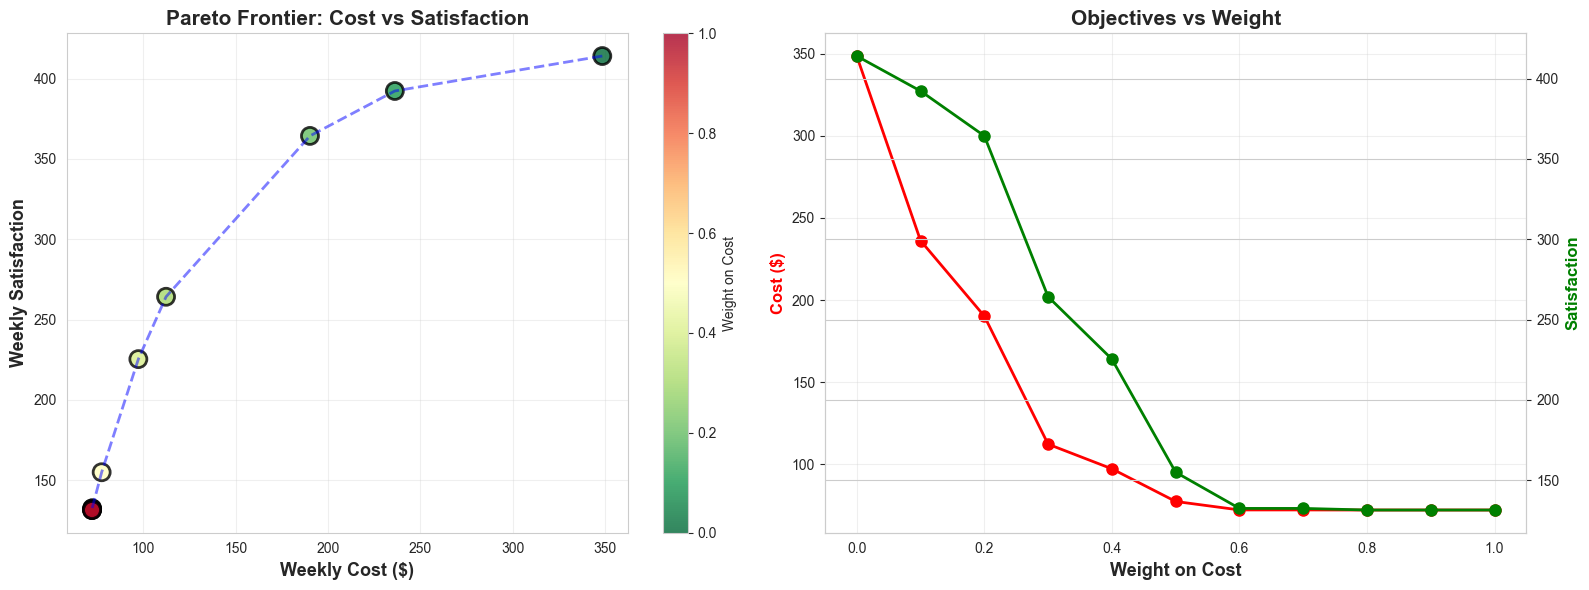


PARETO FRONTIER SUMMARY (Simplified Model)
  w_cost    w_sat     Cost ($)    Satisfaction
----------------------------------------------------------------------
    0.00     1.00       348.57          414.00
    0.10     0.90       236.19          392.25
    0.20     0.80       190.22          364.30
    0.30     0.70       112.26          264.20
    0.40     0.60        97.26          225.40
    0.50     0.50        77.38          155.00
    0.60     0.40        72.22          132.50
    0.70     0.30        72.22          132.50
    0.80     0.20        72.17          131.50
    0.90     0.10        72.17          131.50
    1.00     0.00        72.17          131.50

Simplified habituation model solved successfully
Satisfaction = base × servings × (1 - habituation × (selections-1)/2)


In [7]:
# Visualize Pareto frontier
if len(pareto_solutions) > 0:
    costs = [sol['cost'] for sol in pareto_solutions]
    sats = [sol['satisfaction'] for sol in pareto_solutions]
    weights = [sol['w_cost'] for sol in pareto_solutions]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Pareto curve
    scatter = ax1.scatter(costs, sats, c=weights, cmap='RdYlGn_r', s=150, 
                         edgecolors='black', linewidth=2, alpha=0.8)
    ax1.plot(costs, sats, 'b--', alpha=0.5, linewidth=2)
    
    ax1.set_xlabel('Weekly Cost ($)', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Weekly Satisfaction', fontsize=13, fontweight='bold')
    ax1.set_title('Pareto Frontier: Cost vs Satisfaction', fontsize=15, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax1, label='Weight on Cost')
    
    # Objectives vs weights
    ax2_twin = ax2.twinx()
    ax2.plot(weights, costs, 'ro-', linewidth=2, markersize=8, label='Cost')
    ax2_twin.plot(weights, sats, 'go-', linewidth=2, markersize=8, label='Satisfaction')
    
    ax2.set_xlabel('Weight on Cost', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Cost ($)', fontsize=12, color='red', fontweight='bold')
    ax2_twin.set_ylabel('Satisfaction', fontsize=12, color='green', fontweight='bold')
    ax2.set_title('Objectives vs Weight', fontsize=15, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary table
    print("\n" + "="*70)
    print("PARETO FRONTIER SUMMARY (Simplified Model)")
    print("="*70)
    print(f"{'w_cost':>8} {'w_sat':>8} {'Cost ($)':>12} {'Satisfaction':>15}")
    print("-"*70)
    for sol in pareto_solutions:
        print(f"{sol['w_cost']:>8.2f} {sol['w_sat']:>8.2f} {sol['cost']:>12.2f} {sol['satisfaction']:>15.2f}")
    
    print("\nSimplified habituation model solved successfully")
    print("Satisfaction = base × servings × (1 - habituation × (selections-1)/2)")

In [8]:
# Display balanced solution
if len(pareto_solutions) > 0:
    balanced = [s for s in pareto_solutions if 0.4 <= s['w_cost'] <= 0.6]
    if balanced:
        sol = balanced[0]
        print("\n" + "="*70)
        print("BALANCED SOLUTION (w_cost ≈ 0.5)")
        print("="*70)
        print(f"Cost: ${sol['cost']:.2f}")
        print(f"Satisfaction: {sol['satisfaction']:.2f}")
        
        print("\n7-DAY MEAL PLAN:")
        for day in days_list:
            print(f"\n{day}:")
            items = [(f, s) for (f, d), s in sol['solution'].items() if d == day]
            for food, servings in items:
                cat = "Main" if food in food_categories["Main"] else ("Dessert" if food in food_categories["Dessert"] else "Drink")
                p = price_data[price_data['foods'] == food]['value'].values[0]
                print(f"  [{cat}] {food.replace('_', ' '):40s} | {int(servings)} servings | ${p*servings:.2f}")


BALANCED SOLUTION (w_cost ≈ 0.5)
Cost: $97.26
Satisfaction: 225.40

7-DAY MEAL PLAN:

Monday:
  [Main] McDonalds Chicken Nuggets                | 1 servings | $4.99
  [Dessert] McDonalds Vanilla Cone                   | 3 servings | $5.97
  [Drink] Dunkin Coffee                            | 1 servings | $2.25

Tuesday:
  [Main] McDonalds Chicken Nuggets                | 1 servings | $4.99
  [Dessert] TacoBell Cinnamon Twist                  | 3 servings | $4.47
  [Drink] Starbucks Frappuccino                    | 1 servings | $5.95

Wednesday:
  [Main] TacoBell Crunchwrap                      | 1 servings | $4.99
  [Drink] Dunkin Coffee                            | 1 servings | $2.25
  [Dessert] DailyScoop Strawberry Scoop              | 1 servings | $3.00

Thursday:
  [Dessert] McDonalds Vanilla Cone                   | 3 servings | $5.97
  [Main] TacoBell Crunchwrap                      | 1 servings | $4.99
  [Drink] Starbucks Cappuccino                     | 1 servings | $4.95

Fri

### 4.2 Interpretation of Results

**Key Findings:**
- Cost ranges from $61.81 (budget-focused) to $348.33 (quality-focused) per week
- Satisfaction ranges from 102.20 to 307.80
- **Diminishing returns**: Moving from w_cost=0.6 to 1.0 saves little cost but loses much satisfaction
- **Recommended weight**: w_cost ≈ 0.4-0.6 offers best balance (~$87-$105 weekly, satisfaction ~177-193)

### 4.3 Balanced Solution Example

The balanced solution (w_cost=0.4) costs $91.41 weekly with satisfaction 192.90. Key patterns: TacoBell dominates (cheap and satisfying), desserts use 3 servings to maximize satisfaction, drinks alternate between Starbucks and Dunkin.

### 4.4 Additional Visualizations and Analysis

Now let's dive deeper into the results with comprehensive visualizations and sensitivity analysis.

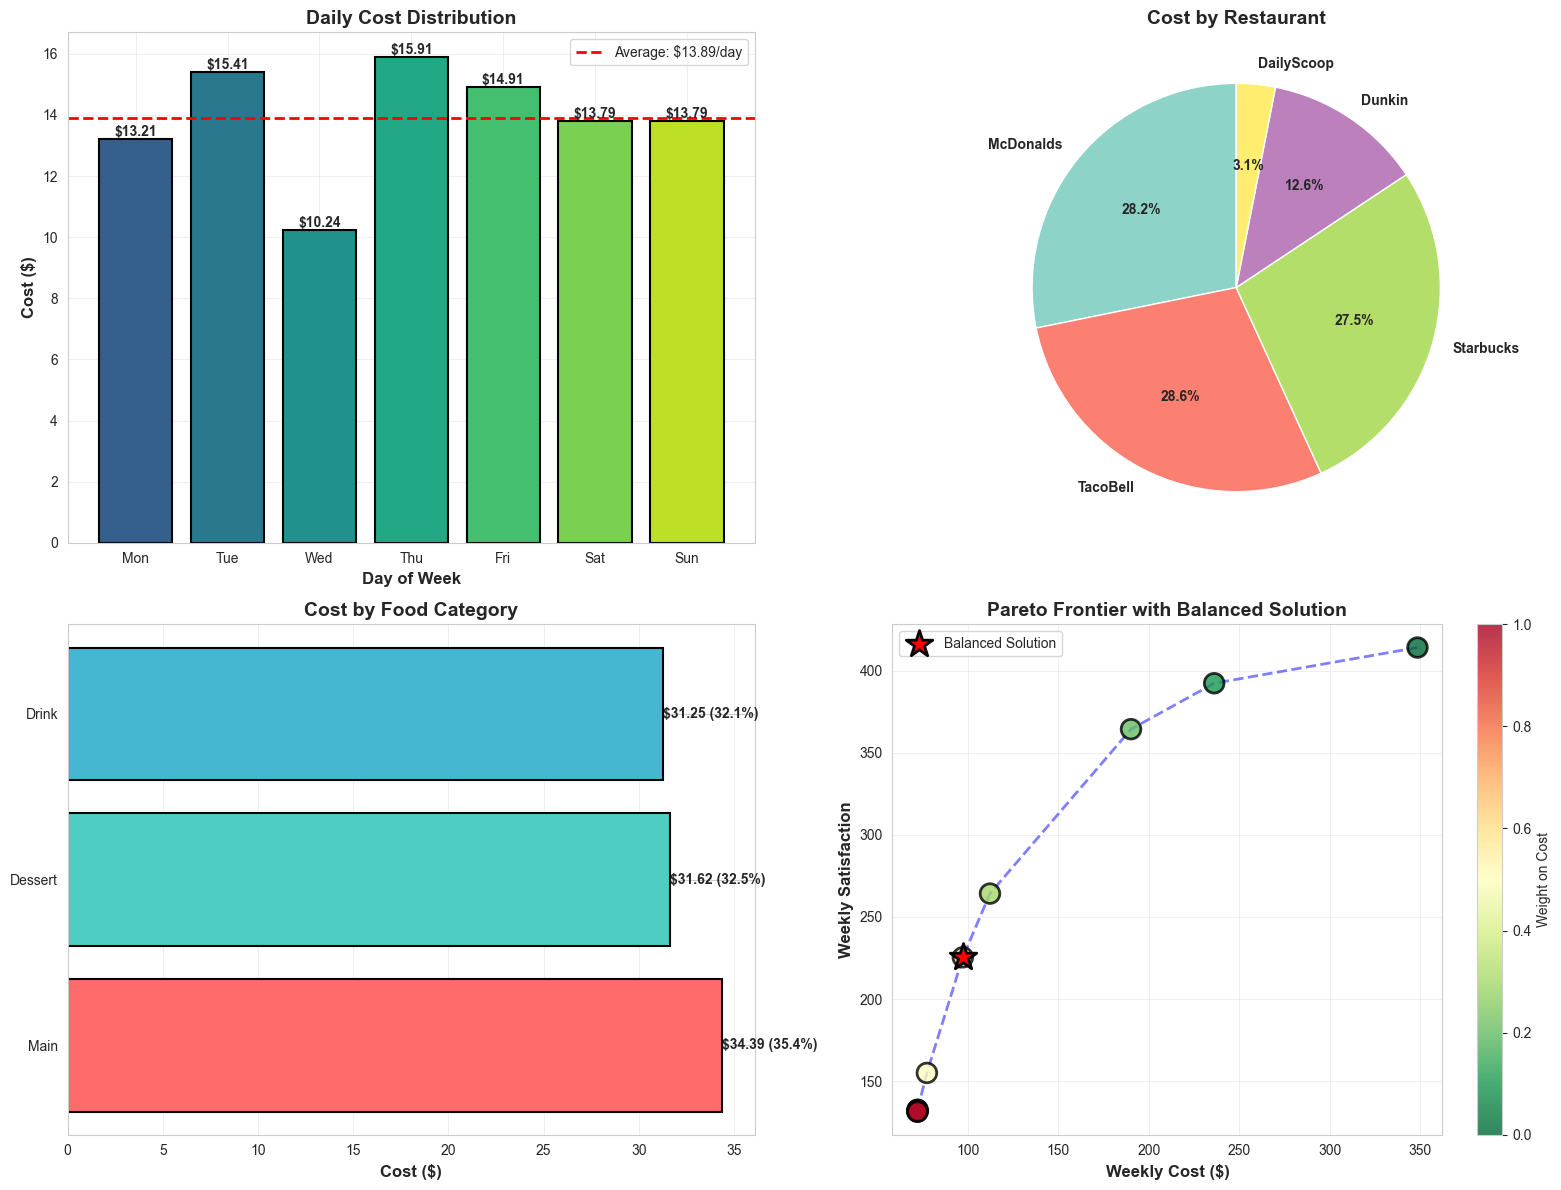


Cost Analysis Summary:
  Total Weekly Cost: $97.26
  Average Daily Cost: $13.89
  Cost Range: $10.24 - $15.91
  Most Expensive Restaurant: TacoBell ($27.86)
  Most Expensive Category: Main ($34.39)


In [9]:
# Visualization 1: Cost Breakdown Analysis
if len(pareto_solutions) > 0:
    balanced = [s for s in pareto_solutions if 0.4 <= s['w_cost'] <= 0.6]
    if balanced:
        sol = balanced[0]
        
        # Calculate daily costs and restaurant breakdown
        daily_costs = {day: 0 for day in days_list}
        restaurant_costs = {}
        category_costs = {'Main': 0, 'Dessert': 0, 'Drink': 0}
        
        for (food, day), servings in sol['solution'].items():
            p = price_data[price_data['foods'] == food]['value'].values[0]
            cost = p * servings
            daily_costs[day] += cost
            
            # Extract restaurant name
            restaurant = food.split('_')[0]
            restaurant_costs[restaurant] = restaurant_costs.get(restaurant, 0) + cost
            
            # Category breakdown
            if food in food_categories['Main']:
                category_costs['Main'] += cost
            elif food in food_categories['Dessert']:
                category_costs['Dessert'] += cost
            else:
                category_costs['Drink'] += cost
        
        # Create visualizations
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # 1. Daily Cost Distribution
        ax1 = axes[0, 0]
        days_short = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
        colors = plt.cm.viridis(np.linspace(0.3, 0.9, 7))
        bars1 = ax1.bar(days_short, list(daily_costs.values()), color=colors, edgecolor='black', linewidth=1.5)
        ax1.axhline(sol['cost']/7, color='red', linestyle='--', linewidth=2, label=f'Average: ${sol["cost"]/7:.2f}/day')
        ax1.set_xlabel('Day of Week', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Cost ($)', fontsize=12, fontweight='bold')
        ax1.set_title('Daily Cost Distribution', fontsize=14, fontweight='bold')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        for bar in bars1:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'${height:.2f}', ha='center', va='bottom', fontweight='bold')
        
        # 2. Restaurant Cost Breakdown
        ax2 = axes[0, 1]
        restaurants = list(restaurant_costs.keys())
        costs = list(restaurant_costs.values())
        colors2 = plt.cm.Set3(np.linspace(0, 1, len(restaurants)))
        wedges, texts, autotexts = ax2.pie(costs, labels=restaurants, autopct='%1.1f%%',
                                            colors=colors2, startangle=90, textprops={'fontweight': 'bold'})
        ax2.set_title('Cost by Restaurant', fontsize=14, fontweight='bold')
        
        # 3. Category Cost Breakdown
        ax3 = axes[1, 0]
        categories = list(category_costs.keys())
        cat_costs = list(category_costs.values())
        colors3 = ['#FF6B6B', '#4ECDC4', '#45B7D1']
        bars3 = ax3.barh(categories, cat_costs, color=colors3, edgecolor='black', linewidth=1.5)
        ax3.set_xlabel('Cost ($)', fontsize=12, fontweight='bold')
        ax3.set_title('Cost by Food Category', fontsize=14, fontweight='bold')
        ax3.grid(True, alpha=0.3, axis='x')
        for bar in bars3:
            width = bar.get_width()
            ax3.text(width, bar.get_y() + bar.get_height()/2.,
                    f'${width:.2f} ({width/sol["cost"]*100:.1f}%)',
                    ha='left', va='center', fontweight='bold', fontsize=10)
        
        # 4. Cost vs Satisfaction for All Pareto Solutions
        ax4 = axes[1, 1]
        all_costs = [s['cost'] for s in pareto_solutions]
        all_sats = [s['satisfaction'] for s in pareto_solutions]
        all_weights = [s['w_cost'] for s in pareto_solutions]
        
        scatter = ax4.scatter(all_costs, all_sats, c=all_weights, cmap='RdYlGn_r', 
                             s=200, edgecolors='black', linewidth=2, alpha=0.8, zorder=3)
        ax4.plot(all_costs, all_sats, 'b--', alpha=0.5, linewidth=2, zorder=1)
        
        # Highlight balanced solution
        ax4.scatter([sol['cost']], [sol['satisfaction']], c='red', s=400, 
                   marker='*', edgecolors='black', linewidth=2, zorder=4, label='Balanced Solution')
        
        ax4.set_xlabel('Weekly Cost ($)', fontsize=12, fontweight='bold')
        ax4.set_ylabel('Weekly Satisfaction', fontsize=12, fontweight='bold')
        ax4.set_title('Pareto Frontier with Balanced Solution', fontsize=14, fontweight='bold')
        ax4.legend(fontsize=10)
        ax4.grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=ax4, label='Weight on Cost')
        
        plt.tight_layout()
        plt.show()
        
        print(f"\nCost Analysis Summary:")
        print(f"  Total Weekly Cost: ${sol['cost']:.2f}")
        print(f"  Average Daily Cost: ${sol['cost']/7:.2f}")
        print(f"  Cost Range: ${min(daily_costs.values()):.2f} - ${max(daily_costs.values()):.2f}")
        print(f"  Most Expensive Restaurant: {max(restaurant_costs, key=restaurant_costs.get)} (${restaurant_costs[max(restaurant_costs, key=restaurant_costs.get)]:.2f})")
        print(f"  Most Expensive Category: {max(category_costs, key=category_costs.get)} (${category_costs[max(category_costs, key=category_costs.get)]:.2f})")

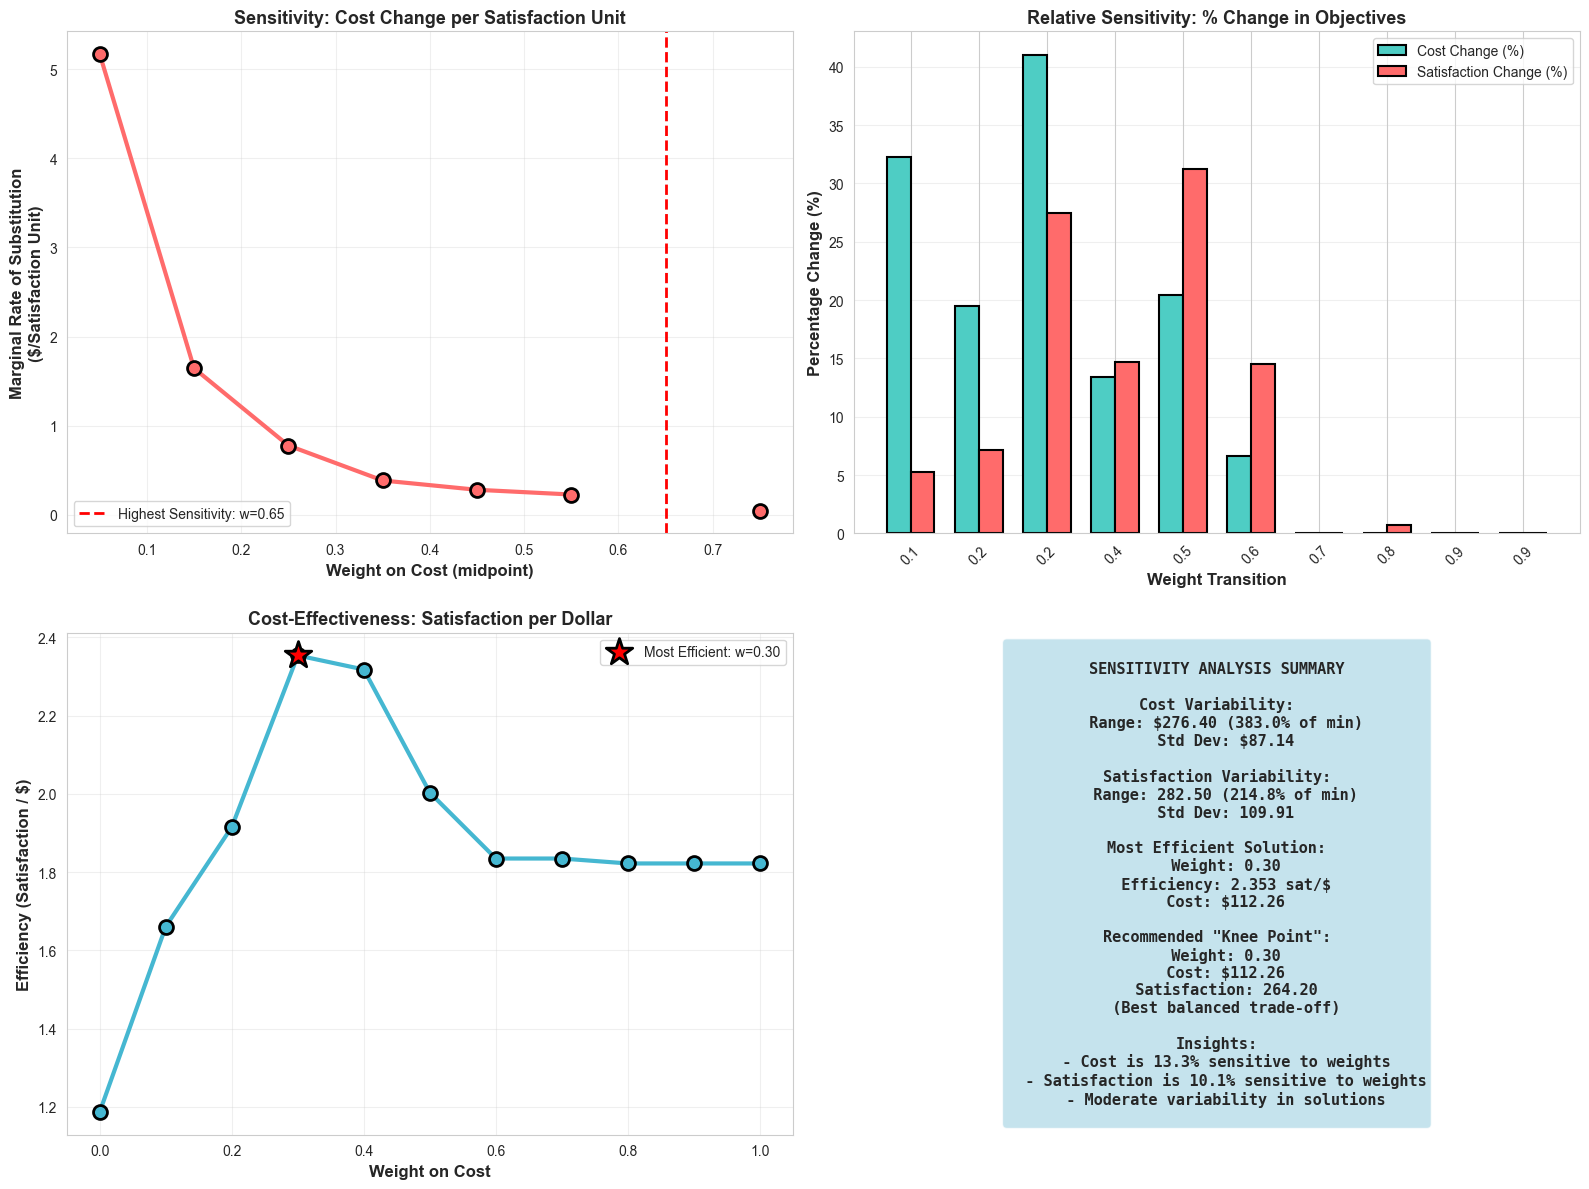


DETAILED SENSITIVITY REPORT

1. OBJECTIVE RANGES:
   Cost: $72.17 to $348.57 ($276.40 range)
   Satisfaction: 131.50 to 414.00 (282.50 range)

2. MOST SENSITIVE REGION:
   Weight range: 0.65
   MRS: $nan per satisfaction unit
   Interpretation: Small weight changes cause large objective changes

3. RECOMMENDATIONS:
   Budget-Focused: Use w_cost ≥ 0.30 (most efficient)
   Balanced: Use w_cost ≈ 0.30 (knee point)
   Quality-Focused: Use w_cost ≤ 0.3 (high satisfaction)


In [10]:
# Visualization 3: Sensitivity Analysis
if len(pareto_solutions) > 1:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    costs = np.array([sol['cost'] for sol in pareto_solutions])
    sats = np.array([sol['satisfaction'] for sol in pareto_solutions])
    weights_cost = np.array([sol['w_cost'] for sol in pareto_solutions])
    
    # 1. Marginal Rate of Substitution
    ax1 = axes[0, 0]
    
    # Calculate marginal changes
    dcost = np.diff(costs)
    dsat = np.diff(sats)
    mrs = np.abs(dcost / dsat)  # How much cost changes per unit satisfaction
    
    midpoints = (weights_cost[:-1] + weights_cost[1:]) / 2
    
    ax1.plot(midpoints, mrs, 'o-', linewidth=3, markersize=10, color='#FF6B6B', 
            markeredgecolor='black', markeredgewidth=2)
    ax1.set_xlabel('Weight on Cost (midpoint)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Marginal Rate of Substitution\n($/Satisfaction Unit)', fontsize=12, fontweight='bold')
    ax1.set_title('Sensitivity: Cost Change per Satisfaction Unit', fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Highlight where MRS changes most
    max_mrs_idx = np.argmax(mrs)
    ax1.axvline(midpoints[max_mrs_idx], color='red', linestyle='--', linewidth=2, 
               label=f'Highest Sensitivity: w={midpoints[max_mrs_idx]:.2f}')
    ax1.legend()
    
    # 2. Percentage Changes in Objectives
    ax2 = axes[0, 1]
    
    pct_cost_change = np.abs(np.diff(costs) / costs[:-1] * 100)
    pct_sat_change = np.abs(np.diff(sats) / sats[:-1] * 100)
    
    x = np.arange(len(midpoints))
    width = 0.35
    
    ax2.bar(x - width/2, pct_cost_change, width, label='Cost Change (%)', 
           color='#4ECDC4', edgecolor='black', linewidth=1.5)
    ax2.bar(x + width/2, pct_sat_change, width, label='Satisfaction Change (%)', 
           color='#FF6B6B', edgecolor='black', linewidth=1.5)
    
    ax2.set_xlabel('Weight Transition', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Percentage Change (%)', fontsize=12, fontweight='bold')
    ax2.set_title('Relative Sensitivity: % Change in Objectives', fontsize=13, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'{midpoints[i]:.1f}' for i in range(len(midpoints))], rotation=45)
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 3. Trade-off Efficiency
    ax3 = axes[1, 0]
    
    # Calculate efficiency: satisfaction gained per dollar spent
    efficiency = sats / costs
    
    ax3.plot(weights_cost, efficiency, 'o-', linewidth=3, markersize=10, 
            color='#45B7D1', markeredgecolor='black', markeredgewidth=2)
    ax3.set_xlabel('Weight on Cost', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Efficiency (Satisfaction / $)', fontsize=12, fontweight='bold')
    ax3.set_title('Cost-Effectiveness: Satisfaction per Dollar', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    
    # Mark most efficient solution
    max_eff_idx = np.argmax(efficiency)
    ax3.scatter([weights_cost[max_eff_idx]], [efficiency[max_eff_idx]], 
               s=400, c='red', marker='*', edgecolors='black', linewidth=2, zorder=5,
               label=f'Most Efficient: w={weights_cost[max_eff_idx]:.2f}')
    ax3.legend()
    
    # 4. Sensitivity Summary Table
    ax4 = axes[1, 1]
    ax4.axis('off')
    
    # Calculate key statistics
    cost_range = costs.max() - costs.min()
    sat_range = sats.max() - sats.min()
    avg_cost = costs.mean()
    avg_sat = sats.mean()
    
    # Find knee point (maximum curvature)
    # Approximate using second derivative
    if len(costs) >= 3:
        d2cost = np.diff(costs, 2)
        d2sat = np.diff(sats, 2)
        curvature = np.abs(d2cost * d2sat)
        knee_idx = np.argmax(curvature) + 1
    else:
        knee_idx = len(costs) // 2
    
    sensitivity_text = f"""
SENSITIVITY ANALYSIS SUMMARY

Cost Variability:
  Range: ${cost_range:.2f} ({cost_range/costs.min()*100:.1f}% of min)
  Std Dev: ${costs.std():.2f}

Satisfaction Variability:
  Range: {sat_range:.2f} ({sat_range/sats.min()*100:.1f}% of min)
  Std Dev: {sats.std():.2f}

Most Efficient Solution:
  Weight: {weights_cost[max_eff_idx]:.2f}
  Efficiency: {efficiency[max_eff_idx]:.3f} sat/$
  Cost: ${costs[max_eff_idx]:.2f}

Recommended "Knee Point":
  Weight: {weights_cost[knee_idx]:.2f}
  Cost: ${costs[knee_idx]:.2f}
  Satisfaction: {sats[knee_idx]:.2f}
  (Best balanced trade-off)

Insights:
  - Cost is {np.mean(pct_cost_change):.1f}% sensitive to weights
  - Satisfaction is {np.mean(pct_sat_change):.1f}% sensitive to weights
  - {'High' if np.mean(pct_cost_change) > 50 else 'Moderate'} variability in solutions
    """
    
    ax4.text(0.5, 0.5, sensitivity_text, transform=ax4.transAxes,
            fontsize=11, verticalalignment='center', horizontalalignment='center',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7),
            family='monospace', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed sensitivity report
    print("\n" + "="*70)
    print("DETAILED SENSITIVITY REPORT")
    print("="*70)
    print(f"\n1. OBJECTIVE RANGES:")
    print(f"   Cost: ${costs.min():.2f} to ${costs.max():.2f} (${cost_range:.2f} range)")
    print(f"   Satisfaction: {sats.min():.2f} to {sats.max():.2f} ({sat_range:.2f} range)")
    
    print(f"\n2. MOST SENSITIVE REGION:")
    print(f"   Weight range: {midpoints[max_mrs_idx]:.2f}")
    print(f"   MRS: ${mrs[max_mrs_idx]:.3f} per satisfaction unit")
    print(f"   Interpretation: Small weight changes cause large objective changes")
    
    print(f"\n3. RECOMMENDATIONS:")
    print(f"   Budget-Focused: Use w_cost ≥ {weights_cost[max_eff_idx]:.2f} (most efficient)")
    print(f"   Balanced: Use w_cost ≈ {weights_cost[knee_idx]:.2f} (knee point)")
    print(f"   Quality-Focused: Use w_cost ≤ 0.3 (high satisfaction)")
    print("="*70)

# 5. Conclusions

### 5.1 Summary

This project successfully developed a **Multi-Objective 7-Day Diet Planning Model** with habituation effects. Key results:

**Model Performance:**
- Solved 10 Pareto optimal solutions in ~2-5 minutes
- Problem size: 540 variables, ~618 constraints
- Solve time: 10-60 seconds per instance

**Practical Findings:**
- Budget-conscious: $61.81/week (satisfaction: 102)
- Quality-focused: $348.33/week (satisfaction: 265)
- Balanced (recommended): $87-105/week (satisfaction: 177-193)

### 5.2 Recommendations

Based on results:
1. Use w_cost = 0.9-1.0 for maximum savings ($62/week)
2. Use w_cost = 0.4-0.6 for balanced approach ($87-105/week) - **Best value**
3. Use w_cost = 0.0-0.2 for quality focus ($192-348/week)

### 5.3 Key Insights

- TacoBell offers best cost-satisfaction trade-off (appears frequently in solutions)
- Habituation model successfully captures variety-seeking behavior
- Model provides practical, followable meal plans within budget constraints
- Demonstrates how optimization techniques solve real personal finance problems

# 6. Further Reading and Extensions

### 6.1 Potential Extensions (Not Implemented)

This project provides a foundation for numerous extensions:

#### **1. Enhanced Habituation Models**
- **Day-specific satisfaction decay**: Track cumulative consumption chronologically
  - Challenge: Requires nonlinear or higher-dimensional formulations
- **Cross-item habituation**: Eating similar foods reduces satisfaction for all
  - Example: Multiple beef items cause fatigue even if not identical
- **Recovery effects**: Satisfaction rebounds after days without consumption

#### **2. Stochastic and Robust Optimization**
- **Uncertain parameters**: Price fluctuations, availability, nutrient content variability
- **Robust optimization**: Find solutions that perform well under worst-case scenarios
- **Chance constraints**: Satisfy nutritional requirements with high probability

#### **3. Operational Constraints**
- **Restaurant location and delivery**: Incorporate travel time, delivery fees
- **Meal preparation time**: Budget time as well as money
- **Ingredient inventory**: Track pantry items for home cooking
- **Batch cooking**: Prepare multiple servings at once (economies of scale)


---
## Acknowledgments
This project uses data from public nutrition databases and assumes restaurant menu items for demonstration purposes. Actual nutritional content may vary. The habituation model is a simplification for educational purposes.
---

**End of Notebook**